# Importing the dependencies

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
path = kagglehub.dataset_download("mehradaria/leukemia")


100%|██████████| 110M/110M [00:00<00:00, 148MB/s]

Extracting files...


# EDA

In [ ]:

path = kagglehub.dataset_download("mehradaria/leukemia")

print("Dataset path:", path)

print("Main folders:", os.listdir(path))


Dataset path: /root/.cache/kagglehub/datasets/mehradaria/leukemia/versions/1
Main folders: ['Original', 'Segmented']


In [ ]:
# Inspect dataset root
os.listdir(path)


['Original', 'Segmented']

In [ ]:
data_dir = os.path.join(path, "Segmented")

print("Classes:", os.listdir(data_dir))


Classes: ['Early', 'Benign', 'Pre', 'Pro']


In [ ]:
image_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    image_counts[class_name] = len(os.listdir(class_path))

print("Image distribution:", image_counts)


Image distribution: {'Early': 985, 'Benign': 504, 'Pre': 963, 'Pro': 804}


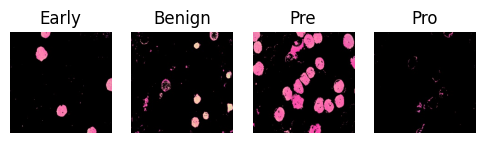

In [ ]:
plt.figure(figsize=(6,6))

classes = os.listdir(data_dir)

for i, class_name in enumerate(classes):
    img_name = os.listdir(os.path.join(data_dir, class_name))[0]
    img_path = os.path.join(data_dir, class_name, img_name)

    img = plt.imread(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()


# Data Preprocessing

In [ ]:
img_size = (128, 128)
batch_size = 32
seed = 42



In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)



Found 3256 files belonging to 4 classes.
Using 2605 files for training.
Found 3256 files belonging to 4 classes.
Using 651 files for validation.


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5153 - loss: 1.0160 - val_accuracy: 0.8049 - val_loss: 0.5130
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7965 - loss: 0.4782 - val_accuracy: 0.8510 - val_loss: 0.4254
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8801 - loss: 0.3219 - val_accuracy: 0.8971 - val_loss: 0.3027
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9275 - loss: 0.2156 - val_accuracy: 0.8940 - val_loss: 0.3326
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9340 - loss: 0.1726 - val_accuracy: 0.9171 - val_loss: 0.2685


In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step - accuracy: 0.9148 - loss: 0.2605
Validation Accuracy: 91.71%


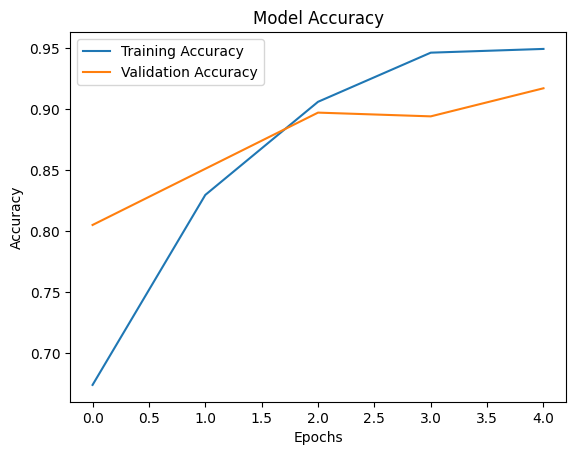

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


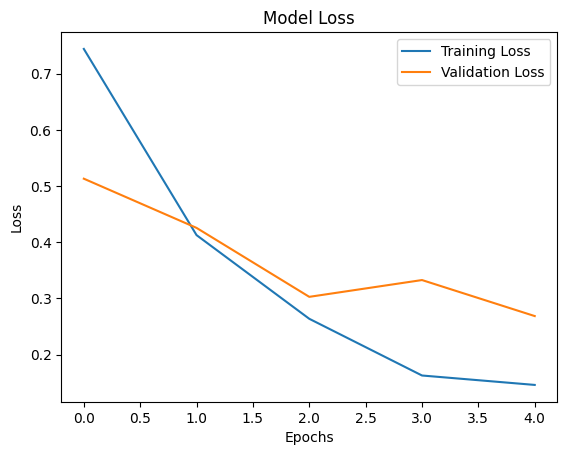

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_ds.class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


AttributeError: '_MapDataset' object has no attribute 'class_names'

In [ ]:
class_names = os.listdir(data_dir)
class_names.sort()  # ensures correct order
print(class_names)


['Benign', 'Early', 'Pre', 'Pro']


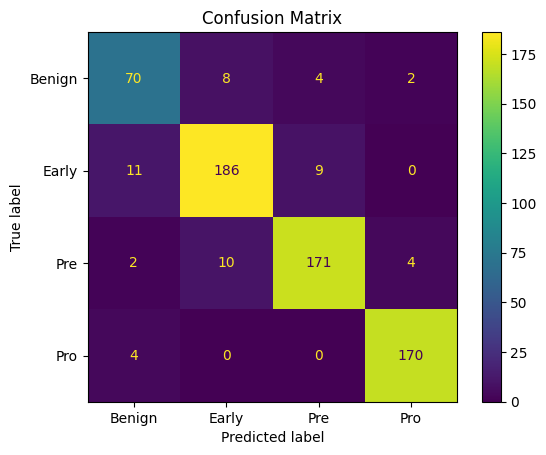

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print("Class index mapping:")
for i, name in enumerate(class_names):
    print(i, "->", name)


Class index mapping:
0 -> Benign
1 -> Early
2 -> Pre
3 -> Pro


In [ ]:
model.save("leukemia_cnn_model.h5")



In [ ]:
import os
import shutil
import random

source_dir = data_dir  # already set earlier (path/Segmented)
output_dir = "/content/leukemia_test_samples"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
samples_per_class = 20

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    target_class_dir = os.path.join(output_dir, class_name)

    os.makedirs(target_class_dir, exist_ok=True)

    images = os.listdir(class_path)
    selected_images = random.sample(images, samples_per_class)

    for img in selected_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(target_class_dir, img)
        shutil.copy(src, dst)

print("Sample test dataset created successfully.")

Sample test dataset created successfully.


In [ ]:
for folder in os.listdir(output_dir):
    print(folder, ":", len(os.listdir(os.path.join(output_dir, folder))), "images")

Early : 20 images
Benign : 20 images
Pre : 20 images
Pro : 20 images


In [ ]:
shutil.make_archive(
    "/content/leukemia_test_samples",
    "zip",
    output_dir
)

'/content/leukemia_test_samples.zip'

In [ ]:
from google.colab import files
files.download("/content/leukemia_test_samples.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>